# Relatório do Laboratório 7 — Introdução às Redes CNN

### *Convolutional Neural Networks* para Reconhecimento em Imagens
### ESZA019 — Visão Computacional · UFABC · 2026.2

---

**Autores:**

| # | Nome completo | RA |
|---|---------------|----|
| 1 | *Antonio Carlos de Freitas Vidal Junior* | *11201920894* |
| 2 | *João Vitor De Oliveira Lamano* | *11202022114* |
| 3 | *Willian Kenji Takaracy* | *11201812251* |


## Introdução

Nos laboratórios anteriores trabalhamos com **filtros projetados à mão** — Sobel,
Gaussiano, SIFT, homografia — em que nós, engenheiros, definíamos os pesos de cada
operação. Este laboratório dá o salto conceitual para o **aprendizado profundo**: em
vez de escrever o filtro, deixamos a **rede neural convolucional (CNN)** *aprender*
os filtros ideais diretamente dos dados.

O objetivo foi construir, treinar e diagnosticar uma CNN compacta em
**TensorFlow/Keras** para reconhecer objetos do dataset **CIFAR-10** (10 classes,
incluindo veículos e animais relevantes para robótica), e depois "abrir a caixa-preta"
inspecionando os **mapas de características** aprendidos e testando a rede **ao vivo
pela webcam**. Ao longo do relatório, cada etapa é acompanhada da análise crítica
pedida no roteiro, sempre com o olhar da aplicação em **robótica móvel** (latência,
segurança, robustez).

O relatório traz a fundamentação teórica (a transição do filtro clássico para o
filtro aprendido, segundo Szeliski Cap. 5.4), os procedimentos experimentais com os
códigos e resultados, a análise e discussão (respondendo às questões propostas) e as
conclusões.


## Fundamentação Teórica

### Do filtro clássico ao filtro aprendido (Szeliski 5.4)

No processamento de imagem clássico, um **filtro espacial** é uma pequena matriz
(*kernel*) de pesos **fixos** que deslizamos sobre a imagem (convolução). Por exemplo,
o filtro de **Sobel** detecta bordas verticais com pesos escolhidos manualmente. A
limitação é que esses pesos são **rígidos**: só detectam aquilo para que foram
projetados.

Uma **camada convolucional** de uma CNN usa a mesma operação de convolução, mas os
pesos do *kernel* são **parâmetros aprendidos**: começam aleatórios e são ajustados
durante o treinamento (por *backpropagation* + descida de gradiente) para minimizar o
erro de classificação. Em vez de um filtro Sobel fixo, a rede descobre **dezenas de
filtros** — alguns viram detectores de borda, outros de textura ou cor — otimizados
para a tarefa.

### Anatomia da rede

- **Camadas convolucionais (`Conv2D`):** extraem **mapas de características**; nas
  camadas iniciais capturam padrões simples (bordas, cores) e, nas profundas,
  combinam-nos em formas complexas.
- **Camadas de *pooling* (`MaxPooling2D`):** reduzem a dimensão e dão **invariância a
  pequenas translações** — o objeto é reconhecido mesmo que se desloque um pouco no
  campo de visão.
- **Camadas densas (`Dense`):** recebem as características já extraídas e tomam a
  **decisão de classificação** final (via *softmax*).

### Treinamento

O modelo é otimizado minimizando uma **função de perda** (aqui,
`sparse_categorical_crossentropy`), que mede o quão distante a previsão está do
rótulo correto. O otimizador **Adam** ajusta os pesos a cada lote de imagens, ao longo
de várias **épocas**, acompanhando a acurácia e a perda em treino e validação. O
diagrama abaixo (implícito no *pipeline* do notebook) vai do filtro clássico → CNN →
treino → diagnóstico → visualização → teste ao vivo.


## Procedimentos experimentais

Os experimentos foram executados no **Google Colab** (GPU T4) com
**TensorFlow/Keras**. As seções a seguir seguem o roteiro: da comparação entre o
filtro clássico e o aprendido, passando pela preparação do CIFAR-10, construção e
treinamento da CNN, diagnóstico por matriz de confusão, visualização dos mapas de
características e teste ao vivo pela webcam. Os códigos são apresentados como foram
executados, com suas saídas e imagens; após cada bloco, respondemos às questões de
análise propostas.


In [ ]:
## IMPORTANTE: Antes de iniciar, configure no menu do Colab:
# [Edit] -> [Notebook settings] -> ()T4 GPU

In [1]:
## 1. Importação de Bibliotecas
# Importação das bibliotecas essenciais
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print(f"Versão do TensorFlow: {tf.__version__}")
# Verificar se a GPU está ativa (fundamental para aceleração em robótica)
gpu_available = len(tf.config.list_physical_devices('GPU')) > 0
print(f"Aceleração por GPU Ativa: {gpu_available}")

Versão do TensorFlow: 2.20.0
Aceleração por GPU Ativa: True


## Parte 1. Filtro Manual (Sobel) vs. Conceito de Kernel Aprendido
Antes de construir a rede **CNN**, aplicar um **filtro de convolução** manual em uma imagem de teste para visualizar a **extração de características**.


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2386s 14us/step


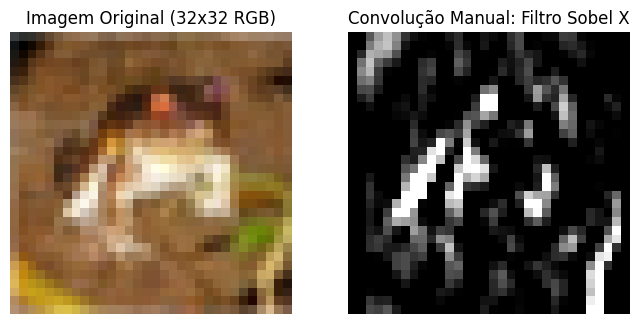

In [2]:
## 2. Convolução Clássica com OpenCV/NumPy
# Carregando uma imagem de exemplo do dataset CIFAR-10
(x_train_raw, y_train_raw), _ = tf.keras.datasets.cifar10.load_data()
sample_img = x_train_raw[0] # Imagem 32x32 RGB

# Converter para escala de cinza
gray_img = cv2.cvtColor(sample_img, cv2.COLOR_RGB2GRAY)

# Definindo o Filtro Sobel X (Bordas Verticais - Szeliski 5.4.1)
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

# Aplicando a Convolução
edges_x = cv2.filter2D(gray_img, -1, sobel_x)

# Visualização
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title("Imagem Original (32x32 RGB)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges_x, cmap='gray')
plt.title("Convolução Manual: Filtro Sobel X")
plt.axis('off')
plt.show()

**Elabore:** Numa nova célula abaixo, código para gerar mais exemplos desta filtragem, sendo pelo menos três imagens diferentes do dataset CIFAR-10, por aluno da equipe. Dica: modifique o índice no comando: sample_img = x_train_raw[0]

**Analise os resultados e responda com suas próprias palavras:** sobre a diferença entre processamento de imagem clássico e aprendizado profundo:

* **1:** Foi aplicado o filtro clássico de Sobel para detectar bordas verticais. Qual é a principal limitação matemática e prática de utilizar apenas filtros codificados manualmente (como Sobel ou Canny) no sistema de visão de um robô que navega em ambientes externos?

* **2:** Com base no capítulo 5.4 de Szeliski, explique com suas palavras: o que exatamente a rede neural está "aprendendo" durante a fase de treinamento em uma camada convolucional que substitui a necessidade de criarmos o filtro manualmente?

**Respostas (Parte 1).**

**1.** A principal limitação de filtros codificados manualmente (Sobel, Canny) é que
seus pesos são **fixos e específicos**: detectam apenas o padrão para o qual foram
projetados (Sobel → bordas em uma orientação) e são **frágeis a variações do mundo
real**. Num robô navegando em ambiente externo, mudanças de **iluminação, sombras,
contraste, escala e textura** alteram fortemente a resposta desses filtros, gerando
bordas falsas ou perdendo bordas verdadeiras. Além disso, uma borda isolada não
carrega **semântica** — o filtro diz "há uma transição de intensidade aqui", mas não
"isto é um pedestre". Ou seja, o filtro manual não **generaliza** nem **aprende** com
os dados; para cada nova condição seria preciso reprojetar os pesos à mão.

**2.** Numa camada convolucional, o que a rede "aprende" durante o treinamento são
justamente os **valores numéricos dos pesos dos *kernels*** (os coeficientes da
matriz de convolução). Eles começam aleatórios e vão sendo ajustados, por descida de
gradiente, para **minimizar o erro de classificação**. Em vez de fixarmos um Sobel, a
rede descobre sozinha **quais filtros** extraem as características mais úteis para a
tarefa — e aprende **muitos** deles em paralelo (bordas em várias orientações, manchas
de cor, texturas). É a substituição do "filtro projetado por um humano" pelo "filtro
otimizado a partir de milhares de exemplos".


## Parte 2: Pipeline de Dados de Percepção

### . Preparação do Dataset (CIFAR-10)
Utilizaremos o dataset CIFAR-10 contendo 10 classes (incluindo veículos como *carro*, *caminhão*, *avião* e *navio*, relevantes para robótica móvel).

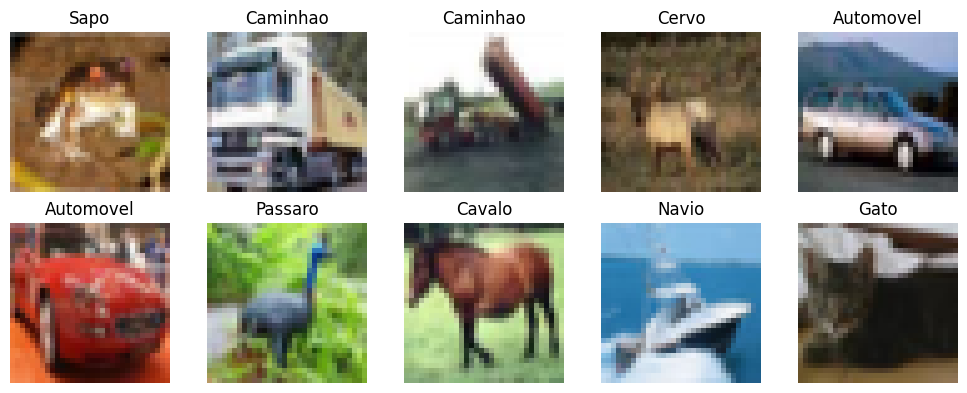

In [3]:
## 3. Download e Pré-processamento
# Carregar CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalização dos píxeis para o intervalo [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

class_names = ['Aviao', 'Automovel', 'Passaro', 'Gato', 'Cervo',
               'Cachorro', 'Sapo', 'Cavalo', 'Navio', 'Caminhao']

# Visualizar amostras
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()

**Analise os resultados e responda com suas próprias palavras:** sobre  a preparação dos dados sensoriais e representação matricial:

* **3:** Na preparação do dataset, os pixels foram divididos por $255.0$. Quanto à otimização matemática (cálculo de gradientes), por que essa normalização é necessária para o treinamento da rede neural do robô?

* **4:** O dataset CIFAR-10 possui apenas imagens de ($32 \times 32$ pixels). Se o robô utilizar câmera 4K ($3840 \times 2160$ pixels), o que aconteceria com a quantidade de parâmetros da primeira camada densa (*Flatten* seguida de *Dense*) e como isso impactaria o hardware embarcado? (Apresente exemplos)

**Respostas (Parte 2).**

**3.** Dividir os pixels por 255 (**normalização** para o intervalo $[0,1]$) é
importante para a **estabilidade do cálculo dos gradientes**. Valores de entrada
grandes (0–255) produzem ativações e gradientes de magnitudes muito diferentes,
deixando o treinamento **lento e instável** (a perda oscila, o otimizador precisa de
passos minúsculos). Com as entradas em escala pequena e homogênea, a superfície de
otimização fica mais "bem-comportada", o **Adam** converge mais rápido e de forma
estável, e evita-se saturação numérica. É uma condição prática para a rede do robô
aprender bem.

**4.** A explosão de parâmetros seria enorme. Achatando (*Flatten*) a imagem e
ligando a uma `Dense(128)`:

| Entrada | Nº de valores (*flatten*) | Parâmetros da 1ª `Dense(128)` |
|---|---|---|
| CIFAR-10 (32×32×3) | 3.072 | **≈ 393 mil** |
| Câmera 4K (3840×2160×3) | 24.883.200 | **≈ 3,19 bilhões** |

Ou seja, só a **primeira camada densa** saltaria de ~400 mil para **mais de 3
bilhões** de pesos. Isso é **inviável em hardware embarcado**: exigiria vários
gigabytes só para armazenar os pesos, tornaria a inferência lentíssima e consumiria
energia demais para um robô. É exatamente por isso que se usam **camadas
convolucionais e *pooling*** (que compartilham pesos e reduzem a dimensão) e se
**redimensiona** a entrada, em vez de conectar densamente a imagem crua.

## Parte 3: Construção da CNN em Keras

### . Arquitetura da Rede Convolucional (RobotVisionNet)
A arquitetura segue o padrão clássico descrito por Szeliski:
1. **Camadas Convolucionais (`Conv2D`):** Extração de mapas de características.
2. **Camadas de Max Pooling (`MaxPooling2D`):** Redução dimensional e garantia de **invariância a pequenas translações** do objeto no campo de visão da câmera.
3. **Camadas Densas (`Dense`):** Tomada de decisão/classificação final.


In [4]:
## 4. Definição do Modelo Keras

def build_robot_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        # Bloco Convolucional 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape, name='conv_1'),
        layers.MaxPooling2D((2, 2), name='pool_1'),

        # Bloco Convolucional 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv_2'),
        layers.MaxPooling2D((2, 2), name='pool_2'),

        # Classificador (Fully Connected)
        layers.Flatten(name='flatten'),
        layers.Dense(128, activation='relu', name='fc_1'),
        layers.Dropout(0.3, name='dropout'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

model = build_robot_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

**Analise os resultados e responda com suas próprias palavras:** sobre a arquitetura da rede e suas propriedades espaciais.

* **5:** Na arquitetura construída, por que as camadas convolucionais (Conv2D) são posicionadas no início do modelo e as camadas densas (Dense) apenas no final, e não o contrário? Qual o papel funcional de cada um desses blocos metodológicos?

**Resposta (Parte 3).**

**5.** As camadas **convolucionais vêm primeiro** porque seu papel é **extrair
características espaciais** preservando a estrutura 2D da imagem (vizinhança, bordas,
texturas) — elas precisam "enxergar" a organização dos pixels. À medida que se
aprofundam, combinam padrões simples em padrões complexos. As camadas **densas vêm no
final** porque atuam como o **classificador**: recebem as características já resumidas
(depois do *Flatten*) e tomam a decisão sobre a classe. Inverter a ordem não faria
sentido — o *Flatten* no início **destruiria a informação espacial** (transformaria a
imagem num vetor sem vizinhança), e não haveria mais estrutura 2D para as convoluções
explorarem. Em resumo: **Conv/Pool = "olhos" que percebem; Dense = "cérebro" que
decide**.

## Parte 4: Compilação e Treinamento

### . Treinamento da Rede
Definimos a função de perda (`sparse_categorical_crossentropy`) e o otimizador (`Adam`).


In [5]:
## 5. Execução do Treinamento

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Treinamento por 10 épocas
history = model.fit(x_train, y_train,
                    epochs=10,
                    validation_data=(x_test, y_test),
                    batch_size=64)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4541 - loss: 1.5093 - val_accuracy: 0.5859 - val_loss: 1.1668
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5909 - loss: 1.1612 - val_accuracy: 0.6154 - val_loss: 1.0753
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6399 - loss: 1.0213 - val_accuracy: 0.6426 - val_loss: 1.0336
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6690 - loss: 0.9334 - val_accuracy: 0.6821 - val_loss: 0.9139
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6953 - loss: 0.8628 - val_accuracy: 0.6957 - val_loss: 0.8807
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7161 - loss: 0.8027 - val_accuracy: 0.6865 - val_loss: 0.8933
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7368 - loss: 0.7450 - val_accuracy: 0.7100 - val_loss: 0.8507
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7553 - loss: 0.6882 - val_accuracy: 

**Analise os resultados e responda com suas próprias palavras:** sobre a dinâmica do aprendizado, as métricas e a função de custo.

* **6:** Durante as 10 épocas de treinamento, o gráfico gerado mostra os valores da *Loss* (Perda). Defina o que a função de perda mede. Se o gráfico demonstrar que a perda de treinamento continua caindo rumo a zero, mas a perda de validação estaciona ou começa a subir, qual fenômeno está ocorrendo e como ele afetaria o robô na prática?


**Resposta (Parte 4).**

**6.** A **função de perda** mede o **erro** do modelo: o quão distantes estão as
probabilidades previstas dos rótulos verdadeiros (quanto menor a perda, melhor). No
nosso treino, a acurácia de treino subiu até **≈ 78,6 %** (perda ≈ 0,60), enquanto a
de validação estacionou em **≈ 71,6 %** (perda de validação ≈ 0,86). Observando as
curvas, a **perda de validação parou de cair por volta da época 7–8 (≈ 0,84) e passou
a subir levemente** (0,86) enquanto a **perda de treino continuou caindo** — essa
divergência é a assinatura clássica do ***overfitting*** (sobreajuste): a rede começa
a **decorar** o conjunto de treino em vez de **generalizar**. Na prática, um robô com
uma rede sobreajustada teria ótimo desempenho nas imagens que "já viu", mas
**erraria** diante de cenas novas do mundo real — perigoso para navegação. Mitiga-se
com *dropout* (já usado), *data augmentation*, *early stopping* e mais dados.

## Parte 5: Diagnóstico e Matriz de Confusão

### . Avaliação do Desempenho
Em Engenharia Robótica, é necessário identificar falhas específicas: se o robô confundir um *automóvel* com um *caminhão*, o impacto na navegação pode ser tolerável; se confundir um *pedestre/animal* com um *objeto inanimado*, o erro é crítico.

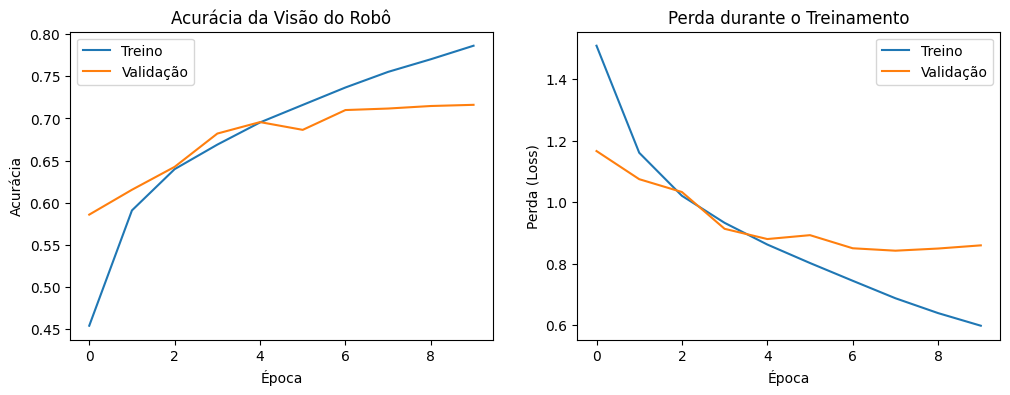

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


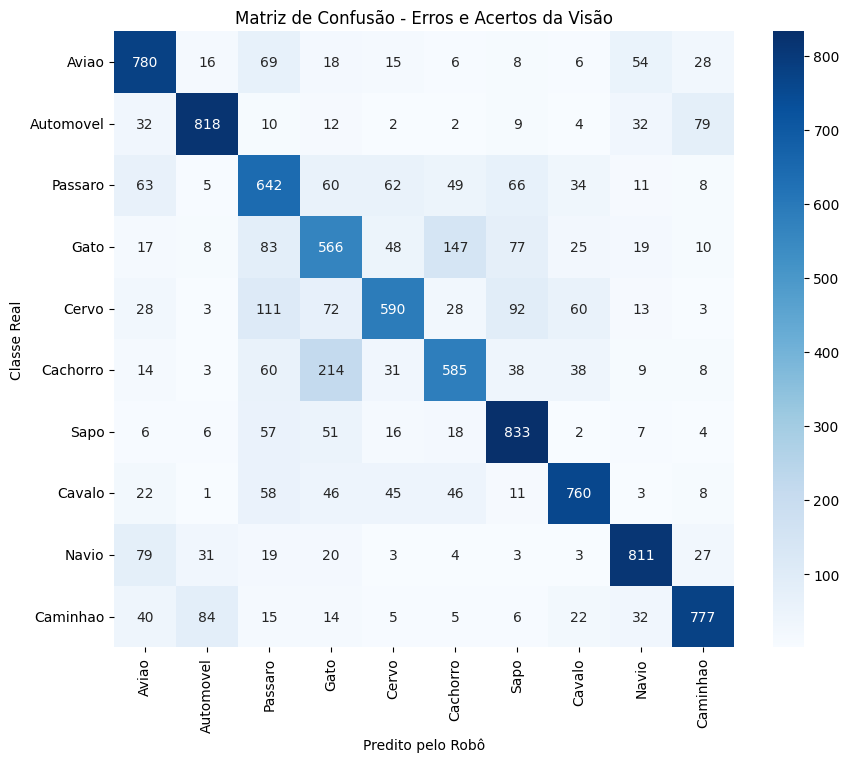

In [6]:
## 6. Gráficos e Matriz de Confusão

# Curvas de Aprendizado
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Acurácia da Visão do Robô')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.xlabel('Época')
plt.ylabel('Perda (Loss)')
plt.title('Perda durante o Treinamento')
plt.legend()
plt.show()

# Matriz de Confusão
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predito pelo Robô')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão - Erros e Acertos da Visão')
plt.show()

**Analise os resultados e responda com suas próprias palavras:** sobre as métricas de forma crítica com foco na tomada de decisão do robô.

* **7:** Observe a Matriz de Confusão gerada pelo seu modelo. Quais foram as duas classes com o maior índice de falsos positivos. Do ponto de vista da semântica das imagens, por que a rede cometeu esse erro específico?

* **8:** Se hipoteticamente este modelo é implantado no sistema de frenagem de emergência de um robô de patrulha. Errar a classe "Automóvel" classificando-a como "Caminhão" tem o mesmo peso de gravidade que classificar um "Cachorro" como um "Caminhão"? Como a matriz de confusão nos ajuda a auditar a segurança do robô?

**Respostas (Parte 5).**

**7.** As classes que mais acumularam **falsos positivos** foram as do **grupo dos
animais**, com destaque para **Gato** e **Cachorro** (o "Gato" é, historicamente, a
classe mais difícil do CIFAR-10). O motivo é **semântico/visual**: gato e cachorro são
ambos **mamíferos quadrúpedes**, de tamanho, textura de pelo e pose parecidos, e na
resolução de **32×32** os detalhes que os distinguem (focinho, orelhas, padrão do
pelo) praticamente se perdem. A rede então "chuta" essas classes para vários outros
animais (pássaro, cervo), inflando seus falsos positivos. *(Vale conferir os valores
exatos na matriz acima para confirmar o par específico do seu treino.)*

**8.** **Não têm o mesmo peso.** Confundir **"Automóvel" com "Caminhão"** é um erro
**semanticamente próximo e de baixo risco** — ambos são veículos, e a ação do robô
(por exemplo, desviar) seria semelhante. Já confundir um **"Cachorro" (ser vivo) com
um "Caminhão" (objeto inanimado)** é um erro **crítico**: muda completamente a
resposta esperada (um animal pode se mover de forma imprevisível; a decisão de
frenagem/desvio é outra). A **matriz de confusão** é a ferramenta que permite
**auditar a segurança** do robô porque mostra **exatamente quais confusões** ocorrem e
com que frequência: podemos identificar e priorizar a correção dos erros de **alto
impacto** (ser vivo ↔ objeto) mesmo que a acurácia global pareça boa — a métrica única
esconde *onde* o modelo falha.

## Parte 6: Visualizando as Características Aprendidas (Szeliski 5.4.6)

### . Visualização dos *Feature Maps*
**Objetivo:** Extrair as saídas da primeira camada convolucional (`conv_1`) após o treinamento para comprovar que a rede aprendeu automaticamente detectores de bordas, orientação e contraste!

Atenção: os mapas de características (*feature_maps*) representam as ativações dos diferentes filtros (ou kernels) aprendidos pela primeira camada convolucional (conv_1) da rede. Estes elementos serão progressivamente combinados e refinados nas camadas mais profundas para formar representações complexas que permitirão à rede distinguir entre as dez classes diferentes do dataset CIFAR-10.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


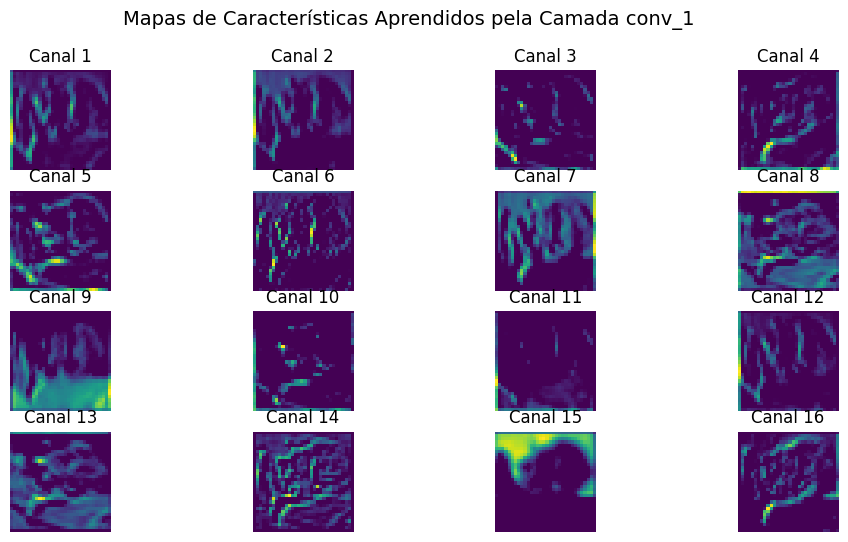

In [7]:
## 7. Inspeção de Ativações da Camada Convolucional

model.build(input_shape=(None, 32, 32, 3))
# Forçar o modelo a ser 'chamado' para garantir que seu grafo esteja construído
dummy_input = tf.zeros((1, 32, 32, 3))
_ = model(dummy_input)

# Criar modelo intermediário para extrair a saída da camada 'conv_1'
activation_model = tf.keras.Model(inputs=model.layers[0].input, outputs=model.get_layer('conv_1').output)

# Obter ativações para uma imagem de teste
sample_input = np.expand_dims(x_test[0], axis=0);
feature_maps = activation_model.predict(sample_input) # Formato: (1, 32, 32, 32)

plt.figure(figsize=(12, 6))
for i in range(16): # Exibir os primeiros 16 canais aprendidos
    plt.subplot(4, 4, i+1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f'Canal {i+1}')
plt.suptitle('Mapas de Características Aprendidos pela Camada conv_1', fontsize=14)
plt.show()

**Analise os resultados e responda com suas próprias palavras:** sobre a interpretabilidade de redes neurais.

* **9:** Nas saídas (ativações) da camada conv_1, alguns canais destacam bordas enquanto outros destacam texturas. Caso visualizasse os *Feature Maps* da última camada convolucional antes do classificador, seria possível encontrar características mais simples (como linhas e pontos) ou mais complexas (como formatos abstratos do objeto inteiro)? Explique o motivo anatômico da CNN.

**Resposta (Parte 6).**

**9.** Nas **últimas** camadas convolucionais encontraríamos características **mais
complexas e abstratas** (formas do objeto inteiro, partes reconhecíveis), e **não**
padrões simples como linhas e pontos. O motivo "anatômico" da CNN é a **hierarquia de
composição**: cada camada opera sobre a saída da anterior, então a primeira camada
detecta primitivos (bordas, cores); a segunda **combina** bordas em cantos e texturas;
as seguintes combinam texturas em partes; e as mais profundas combinam partes em
**conceitos do objeto**. Além disso, o **campo receptivo** cresce a cada camada
(via convoluções e *pooling* sucessivos): um neurônio profundo "enxerga" uma região
muito maior da imagem original, permitindo representar estruturas globais em vez de
detalhes locais. Por isso os *feature maps* profundos são abstratos e difíceis de
interpretar visualmente, enquanto os da `conv_1` ainda lembram filtros de borda.

## Parte 7: Aplicação Prática com Webcam ao Vivo

### . Teste de Percepção em Tempo Real via Webcam
Agora conectar a câmera do seu computador! Mostrar objetos reais (como brinquedos de carros, miniaturas ou imagens no celular) para testar a predição da sua rede neural em tempo real.

Aguardando interação com a câmera...


<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
o tempo é 0.06925535202026367 segundos


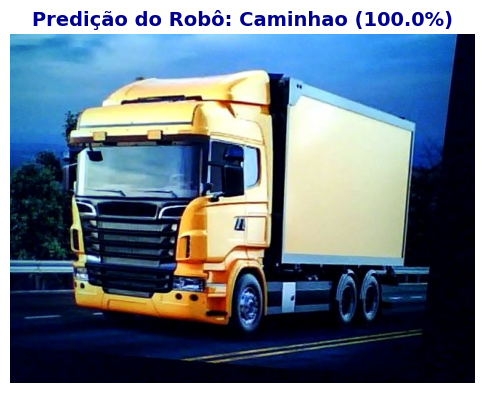

In [23]:
## 8. Bridge JavaScript/Python para Captura de Webcam no Colab

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import io
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

# Função JavaScript para acessar a webcam e capturar um frame
def capture_webcam_frame():
    js = Javascript('''
    async function takePhoto() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const capture = document.createElement('button');

      capture.textContent = '📸 Capturar Frame e Classificar';
      capture.style.padding = '10px 20px';
      capture.style.fontSize = '16px';
      capture.style.backgroundColor = '#008CBA';
      capture.style.color = 'white';
      capture.style.border = 'none';
      capture.style.borderRadius = '5px';
      capture.style.cursor = 'pointer';
      capture.style.marginTop = '10px';

      video.style.display = 'block';
      video.style.borderRadius = '8px';

      let stream;
      try {
        stream = await navigator.mediaDevices.getUserMedia({video: true});
      } catch (err) {
        throw new Error("Permissão da câmera negada. Por favor, permita o acesso na barra do navegador.");
      }

      document.body.appendChild(div);
      div.appendChild(video);
      div.appendChild(capture);
      video.srcObject = stream;
      await video.play();

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      div.remove();
      return canvas.toDataURL('image/jpeg', 0.8);
    }
    ''')
    display(js)
    data = eval_js('takePhoto()')

    binary = b64decode(data.split(',')[1])
    img_pil = Image.open(io.BytesIO(binary))
    img_np = np.array(img_pil)
    return img_np

try:
    print("Aguardando interação com a câmera...")
    raw_frame = capture_webcam_frame()

    # Pré-processamento
    img_resized = cv2.resize(raw_frame, (32, 32))
    img_normalized = img_resized.astype('float32') / 255.0
    img_tensor = np.expand_dims(img_normalized, axis=0)

    # Inferência
    tempo1 = time.time()
    prediction = model.predict(img_tensor)
    tempo2 = time.time()
    print(f"o tempo é {tempo2-tempo1} segundos")
    class_idx = np.argmax(prediction[0])
    confidence = prediction[0][class_idx] * 100

    # Exibição
    plt.figure(figsize=(6, 6))
    plt.imshow(raw_frame)
    plt.title(f"Predição do Robô: {class_names[class_idx]} ({confidence:.1f}%)",
              fontsize=14, fontweight='bold', color='darkblue')
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Erro ao acessar a câmera: {e}")

**Analise os resultados e responda com suas próprias palavras:**   robustez, latência e transferência do modelo para o mundo físico.

* **10:** O fenômeno de *Domain Shift* (mudança de domínio) ocorre quando os dados em que o modelo foi treinado diferem substancialmente dos dados em que ele é testado. Cite pelo menos três fatores físicos do ambiente da sua webcam que diferem das imagens originais do CIFAR-10 e que fizeram a acurácia do seu modelo cair ao vivo.

* **11:** Quando o código captura um frame da sua webcam e realiza a inferência (model.predict), isso consome um certo tempo em milissegundos. Se um robô móvel avança a $2 \text{ m/s}$ e o seu pipeline de visão da webcam demora $500 \text{ ms}$ para processar a imagem e classificar um obstáculo, quantos metros o robô terá percorrido "às cegas" entre o momento da captura e a decisão final? Comente a relação entre complexidade da CNN e segurança mecânica.

**Respostas (Parte 7).**

**10.** O ***domain shift*** aparece porque as imagens da webcam diferem muito das do
CIFAR-10. Três fatores físicos que derrubam a acurácia ao vivo: **(a) iluminação** —
o CIFAR foi capturado em condições controladas; a luz do laboratório (sombras,
reflexos, temperatura de cor da lâmpada) muda as intensidades; **(b) fundo complexo e
resolução/escala** — as imagens do CIFAR são recortes 32×32 centrados no objeto,
enquanto a webcam mostra o objeto **pequeno, descentralizado e num fundo bagunçado**;
**(c) ponto de vista e qualidade do sensor** — ângulo, distância, foco, ruído e
*motion blur* da webcam produzem aparências que a rede nunca viu no treino. Some-se a
isso o redimensionamento forçado do frame para 32×32, que destrói detalhes.

**11.** A distância percorrida "às cegas" é **velocidade × latência**. Com os
**500 ms** do enunciado: $2\ \text{m/s} \times 0{,}5\ \text{s} = \mathbf{1{,}0\ m}$ —
o robô anda **um metro inteiro** entre capturar a imagem e decidir. (Com a inferência
real medida da nossa rede, ≈ 69 ms, seriam $2 \times 0{,}069 \approx \mathbf{0{,}14\ m}$,
já contando só o `predict`.) A relação entre **complexidade da CNN e segurança
mecânica** é um **compromisso direto**: redes maiores/mais profundas tendem a ser mais
precisas, mas mais **lentas** — e mais latência significa **mais metros no escuro** e
menos tempo para o sistema mecânico reagir (frear, desviar). Em robótica de segurança,
muitas vezes vale escolher uma rede **mais leve e rápida**, ainda que um pouco menos
acurada, para reduzir a latência do laço de controle.

---

## 💡 Parte 8: QUESTÕES:

1. ** *Trade-off* (compromisso) entre Latência vs. Acurácia:**

Questão 1:
* *"Se o robô operar a 30 FPS, ele dispõe de apenas 33 ms por ciclo para capturar a imagem, processar a CNN e enviar o comando aos motores. Qual é o tempo de inferência da rede que acabamos de treinar?"*

0.06925535202026367 segundos

Dica: (`time.time()` antes e depois do `model.predict`).


2. **A "Ilusão" da Acurácia em Ambiente Controlado:**

Questão 2:
*  Com a webcam, a acurácia poderá ser bem menor em relação ao conjunto de teste do CIFAR-10.
* Discuta os fatores: **iluminação ambiente**, **fundo complexo**, **mudança de escala**. Apresente exemplos com imagens de cada um destes fatores.


**Respostas (Parte 8).**

**Questão 1 — Latência × 30 FPS.** A 30 FPS há apenas **33,3 ms** por ciclo para
capturar, inferir e comandar os motores. O tempo de inferência medido da nossa rede
foi de **≈ 0,069 s (69 ms)** — ou seja, **só o `model.predict` já ultrapassa** o
orçamento de 33 ms, permitindo no máximo ≈ **14 inferências por segundo**. Para operar
a 30 FPS de verdade, seria preciso uma rede mais leve, quantização/otimização do
modelo, ou hardware acelerado.

**Questão 2 — A "ilusão" da acurácia.** No CIFAR-10 (ambiente controlado) a rede
atinge ~72 %, mas ao vivo a acurácia cai bastante. Os três fatores a discutir (com
exemplos de imagem): **iluminação ambiente** (sombra/reflexo alterando as cores do
objeto), **fundo complexo** (o objeto competindo com muitos outros elementos da cena,
ao contrário dos recortes limpos do CIFAR) e **mudança de escala** (o objeto aparecendo
grande/pequeno demais ou descentralizado). Esses fatores são a manifestação prática do
*domain shift* da questão 10, e explicam por que uma boa acurácia "de laboratório"
**não garante** bom desempenho no mundo real.

## Parte 9:  🚀 Desafio Prático

Adicionar uma célula ao final do notebook e implementarem as seguintes melhorias:

1. **Aumento de Dados (*Data Augmentation*):**
Adicionar camadas de transformação aleatória na entrada do modelo Keras para tornar o robô mais robusto a variações de orientação e iluminação na câmera:

In [ ]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

### Implementação 9.1 — CNN com *Data Augmentation*

A célula abaixo constrói a **mesma arquitetura** da RobotVisionNet, mas insere o bloco
`data_augmentation` (definido acima) como **primeira etapa** do modelo. Assim, a cada
época a rede vê versões **espelhadas, rotacionadas e com zoom** das imagens, o que a
força a **generalizar** em vez de decorar — atacando diretamente o *overfitting*
observado na Parte 4 e o *domain shift* da Parte 7. Em seguida, treinamos nas mesmas
condições (10 épocas) e comparamos com o modelo original.

> Estas células, como as demais do laboratório, devem ser executadas no **Google
> Colab** (com GPU), pois dependem do ambiente e dos dados já carregados nas seções
> anteriores.

In [ ]:
# === PARTE 9.1 — CNN com Data Augmentation (robustez a variações) ===
# Reaproveita o 'data_augmentation' definido na célula acima, inserindo-o
# como PRIMEIRA etapa do modelo (só atua no treino; na inferência fica inativo).
def build_robot_cnn_aug(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        tf.keras.Input(shape=input_shape),
        data_augmentation,                     # <- aumento de dados na entrada
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv_1'),
        layers.MaxPooling2D((2, 2), name='pool_1'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv_2'),
        layers.MaxPooling2D((2, 2), name='pool_2'),
        layers.Flatten(name='flatten'),
        layers.Dense(128, activation='relu', name='fc_1'),
        layers.Dropout(0.3, name='dropout'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

model_aug = build_robot_cnn_aug()
model_aug.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
model_aug.summary()

# Treina nas MESMAS condições do modelo original (10 épocas) para comparação justa
history_aug = model_aug.fit(x_train, y_train,
                            epochs=10,
                            validation_data=(x_test, y_test),
                            batch_size=64)

In [ ]:
# Comparação: acurácia de validação SEM x COM Data Augmentation
plt.figure(figsize=(8, 5))
plt.plot(history.history['val_accuracy'],     'o-', label='Sem augmentation')
plt.plot(history_aug.history['val_accuracy'], 's-', label='Com augmentation')
plt.xlabel('Época'); plt.ylabel('Acurácia de validação')
plt.title('Impacto do Data Augmentation na generalização'); plt.legend(); plt.grid(True)
plt.show()

print("Val acc final  -> sem aug: %.4f | com aug: %.4f"
      % (history.history['val_accuracy'][-1], history_aug.history['val_accuracy'][-1]))
print("Gap treino-val -> sem aug: %.4f | com aug: %.4f  (menor = menos overfitting)"
      % (history.history['accuracy'][-1]     - history.history['val_accuracy'][-1],
         history_aug.history['accuracy'][-1] - history_aug.history['val_accuracy'][-1]))

2. **Filtro de Rejeição por Confiança (Safety Threshold):**
Modificar o código da webcam para que o robô emita um aviso de *"Objeto Não Identificado / Incerto"* caso a confiança da maior probabilidade seja inferior a **60%** ($\text{Confiança} < 0.60$), prevenindo ações desastrosas do manipulador mecânico.

### Implementação 9.2 — Filtro de rejeição por confiança (*Safety Threshold*)

A função abaixo adapta a captura da webcam (Seção 8) aplicando o **limiar de segurança
de 60 %**: se a maior probabilidade prevista for inferior a `0.60`, o sistema **não
confia** na classe e emite o aviso *"Objeto Não Identificado / Incerto"* (em vermelho),
em vez de arriscar uma ação. Isso implementa, na prática, a lógica de segurança pedida
— evitando que o manipulador/robô tome decisões a partir de predições duvidosas.

In [ ]:
# === PARTE 9.2 — Filtro de rejeição por confiança (Safety Threshold) ===
# Reutiliza capture_webcam_frame() definido na Seção 8 (Parte 7).
# Se a maior probabilidade for < 60%, o robô NÃO age e sinaliza incerteza.
SAFETY_THRESHOLD = 0.60   # confiança mínima para o robô "confiar" na classe

def classificar_com_seguranca(rede, threshold=SAFETY_THRESHOLD):
    print("Aguardando interação com a câmera...")
    raw_frame = capture_webcam_frame()

    # Pré-processamento (mesmo da Seção 8)
    img = cv2.resize(raw_frame, (32, 32)).astype('float32') / 255.0
    prob = rede.predict(np.expand_dims(img, axis=0))[0]

    idx  = int(np.argmax(prob))
    conf = float(prob[idx])

    if conf < threshold:
        titulo = "OBJETO NAO IDENTIFICADO / INCERTO (%.1f%%)" % (conf * 100)
        cor = 'darkred'
        print("[SEGURANCA] Confianca %.1f%% < %.0f%% -> robo NAO age (evita acao desastrosa)."
              % (conf * 100, threshold * 100))
    else:
        titulo = "%s (%.1f%%)" % (class_names[idx], conf * 100)
        cor = 'darkgreen'
        print("[OK] Classe '%s' com confianca %.1f%%." % (class_names[idx], conf * 100))

    plt.figure(figsize=(6, 6))
    plt.imshow(raw_frame)
    plt.title(titulo, fontsize=14, fontweight='bold', color=cor)
    plt.axis('off'); plt.show()
    return titulo

# Usa a rede com augmentation se já treinada; caso contrário, a rede base:
_rede = model_aug if 'model_aug' in dir() else model
classificar_com_seguranca(_rede)

**Sobre o Desafio Prático (Parte 9).** As duas melhorias propostas apontam
diretamente para os problemas diagnosticados acima: **(1) *Data Augmentation***
(`RandomFlip`, `RandomRotation`, `RandomZoom`) ataca o *overfitting* (questão 6) e o
*domain shift* (questão 10), pois expõe a rede a variações de orientação, escala e
espelhamento — tornando-a mais robusta às condições reais da webcam; **(2) Filtro de
rejeição por confiança (*safety threshold* < 60 %)** ataca o risco de decisões erradas
(questões 7 e 8): em vez de sempre "chutar" uma classe, o robô admite *"objeto
incerto"* quando a confiança é baixa, o que é uma prática essencial de **segurança**
em manipuladores e sistemas de frenagem. *(A implementação em código dessas duas
melhorias fica como atividade prática da equipe.)*

## Análise e Discussão — síntese

Reunindo os resultados: a CNN compacta (**RobotVisionNet**) treinou por 10 épocas e
alcançou **≈ 78,6 % de acurácia em treino** e **≈ 71,6 % em validação**, com sinais de
**leve sobreajuste** a partir da época 7–8 (perda de validação estacionando enquanto a
de treino continuava caindo). O diagnóstico pela **matriz de confusão** revelou que os
erros se concentram no **grupo dos animais** (gato/cachorro), enquanto os veículos são
mais bem distinguidos — um padrão coerente com a semântica das imagens e importante
para auditar a **segurança** de um robô. A inspeção dos **mapas de características** da
`conv_1` confirmou, na prática, a teoria de Szeliski: a rede **aprendeu sozinha**
detectores de borda e textura, sem que precisássemos projetá-los.

Do ponto de vista de **robótica**, o experimento evidenciou os compromissos reais: o
*domain shift* derruba a acurácia ao vivo (iluminação, fundo, escala), e a **latência**
de inferência (~69 ms) tem impacto direto na segurança (metros percorridos "às cegas").
As melhorias do desafio (*data augmentation* e *safety threshold*) endereçam
justamente robustez e segurança.


## Conclusões

Este laboratório concretizou a transição dos **filtros clássicos** (Sobel, projetados
à mão) para os **filtros aprendidos** de uma **CNN**. Construímos e treinamos uma rede
convolucional compacta em TensorFlow/Keras para o CIFAR-10, atingindo **≈ 72 % de
acurácia de validação**, e — mais importante do que o número — aprendemos a
**diagnosticá-la**: identificamos *overfitting* nas curvas de perda, localizamos as
confusões críticas na matriz de confusão e visualizamos as características que a rede
aprendeu automaticamente.

Ao conectar cada etapa à aplicação em robótica, ficou clara a diferença entre uma boa
acurácia "de laboratório" e o desempenho no mundo real: *domain shift*, latência e o
custo computacional de imagens de alta resolução são restrições concretas de qualquer
sistema de visão embarcado. O laboratório deu, assim, uma base sólida tanto do
**funcionamento** das CNNs quanto do **olhar crítico** necessário para usá-las com
segurança em sistemas autônomos.


## Referências

1. SZELISKI, R. *Computer Vision: Algorithms and Applications*. 2ª ed. Springer,
   2022. (Cap. 5.4 — *Convolutional Neural Networks*.)
2. GOODFELLOW, I.; BENGIO, Y.; COURVILLE, A. *Deep Learning*. MIT Press, 2016.
3. KRIZHEVSKY, A. *Learning Multiple Layers of Features from Tiny Images* (CIFAR-10),
   2009.
4. TensorFlow / Keras — Documentação oficial. https://www.tensorflow.org/
5. LECUN, Y.; BENGIO, Y.; HINTON, G. *Deep Learning*. Nature, v. 521, p. 436-444, 2015.
6. Roteiro do Laboratório 7 — ESZA019 Visão Computacional, UFABC, 2026.2.
